In [2]:
# Install RAPIDS and cuML using the rapids-colab package for better compatibility.
# This installation can take several minutes and might require a runtime restart.
!pip install -q condacolab
import condacolab
condacolab.install()

# After condacolab is installed and runtime potentially restarted, then install cuml.
# This specific version works well with the current Colab environment and CUDA 12.
# Explicitly specifying python=3.11 to align with condacolab's installed python version.
!mamba install -c rapidsai -c conda-forge -c nvidia cuml=24.02 python=3.11 cudatoolkit=12.0 --yes

✨🍰✨ Everything looks OK!

Looking for: ['cuml=24.02', 'python=3.11', 'cudatoolkit=12.0']

rapidsai/linux-64                                           Using cache
rapidsai/noarch                                             Using cache
conda-forge/linux-64                                        Using cache
conda-forge/noarch                                          Using cache
nvidia/linux-64                                             Using cache
nvidia/noarch                                               Using cache
Your pinning does not match what's currently installed. Please remove the pin and fix your installation
  Pin: python=3.12
  Currently installed: conda-forge/linux-64::python==3.11.11=h9e4cc4f_1_cpython


In [3]:
# imports
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

In [4]:
# Dataloader

file_name = "/content/drive/My Drive/Colab Notebooks/Machine_Learning_Course/diabetes_012_health_indicators_BRFSS2015.csv"
df = pd.read_csv(file_name)

num_rows, num_cols = df.shape
print(f"Total rows: {num_rows}")
print(f"Total labels (columns): {num_cols}")

X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("\nDataset split:")
print(f"Train set: {len(X_train)} rows")
print(f"Validation set: {len(X_val)} rows")
print(f"Test set: {len(X_test)} rows")

X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

Total rows: 253680
Total labels (columns): 22

Dataset split:
Train set: 177576 rows
Validation set: 38052 rows
Test set: 38052 rows


In [ ]:
from sklearn.svm import SVC

# Define the pipeline for Kernel SVM
kernel_svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', decision_function_shape='ovr')) # 'ovr' for multiclass
])

# Define the parameter grid for GridSearchCV
# Reduced for faster execution
param_grid = {
    'svm__C': [1],
    'svm__gamma': [0.1]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(kernel_svm_pipeline, param_grid, cv=3, scoring='f1_weighted', n_jobs=-1, verbose=2)

print("Kernel SVM pipeline and parameter grid defined. Starting GridSearchCV...")

Kernel SVM pipeline and parameter grid defined. Starting GridSearchCV...


In [ ]:
import time

# To get an immediate result, we will sample a small subset of the data.
# For the full dataset, consider GPU-accelerated libraries (e.g., cuML, sklearnex) or more scalable models.
# For example, let's use 10% of the training+validation data for a quick run.
sample_size = 0.1 # You can adjust this percentage

X_trainval_sampled, _, y_trainval_sampled, _ = train_test_split(
    X_trainval, y_trainval, test_size=1-sample_size, random_state=42, stratify=y_trainval
)

print(f"Fitting GridSearchCV on a sampled dataset of size: {len(X_trainval_sampled)} rows")

# Fit GridSearchCV on the sampled training and validation data
start_time = time.time()
grid_search.fit(X_trainval_sampled, y_trainval_sampled)
end_time = time.time()

print(f"GridSearchCV completed in {end_time - start_time:.2f} seconds.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best parameters found: {best_params}")
print(f"Best F1-weighted score (cross-validation): {best_score:.4f}")

# Get the best model
best_kernel_svm_model = grid_search.best_estimator_

Fitting GridSearchCV on a sampled dataset of size: 21562 rows
Fitting 3 folds for each of 1 candidates, totalling 3 fits
GridSearchCV completed in 65.83 seconds.
Best parameters found: {'svm__C': 1, 'svm__gamma': 0.1}
Best F1-weighted score (cross-validation): 0.7961


In [ ]:
# Evaluate the best model on the test set
y_pred = best_kernel_svm_model.predict(X_test)

# Calculate and print evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
class_report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nTest Set Accuracy: {accuracy:.4f}")
print(f"Test Set F1-weighted Score: {f1:.4f}")
print(f"Test Set Precision (weighted): {precision:.4f}")
print(f"Test Set Recall (weighted): {recall:.4f}")
print("\nClassification Report:\n", class_report)
print("\nConfusion Matrix:\n", conf_matrix)


Test Set Accuracy: 0.8463
Test Set F1-weighted Score: 0.7981
Test Set Precision (weighted): 0.7970
Test Set Recall (weighted): 0.8463

Classification Report:
               precision    recall  f1-score   support

         0.0       0.86      0.99      0.92     32055
         1.0       0.00      0.00      0.00       695
         2.0       0.55      0.12      0.19      5302

    accuracy                           0.85     38052
   macro avg       0.47      0.37      0.37     38052
weighted avg       0.80      0.85      0.80     38052


Confusion Matrix:
 [[31592     0   463]
 [  653     0    42]
 [ 4689     0   613]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


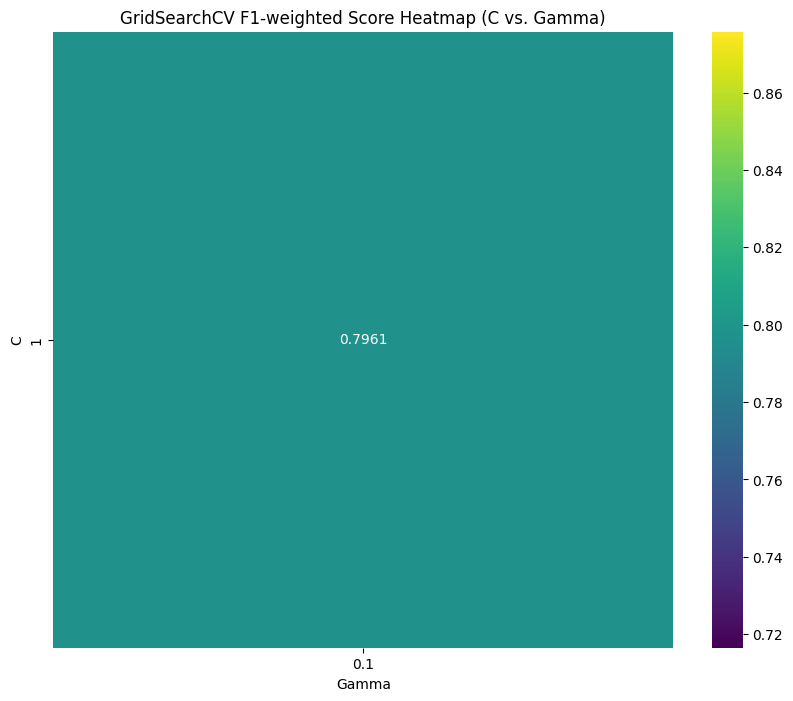

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get results from GridSearchCV
results = pd.DataFrame(grid_search.cv_results_)

# Pivot the table to get C on one axis and gamma on the other, with F1-weighted as values
scores_heatmap = results.pivot_table(index='param_svm__C',
                                     columns='param_svm__gamma',
                                     values='mean_test_score') # Corrected column name

plt.figure(figsize=(10, 8))
sns.heatmap(scores_heatmap, annot=True, cmap='viridis', fmt=".4f")
plt.title('GridSearchCV F1-weighted Score Heatmap (C vs. Gamma)')
plt.xlabel('Gamma')
plt.ylabel('C')
plt.show()

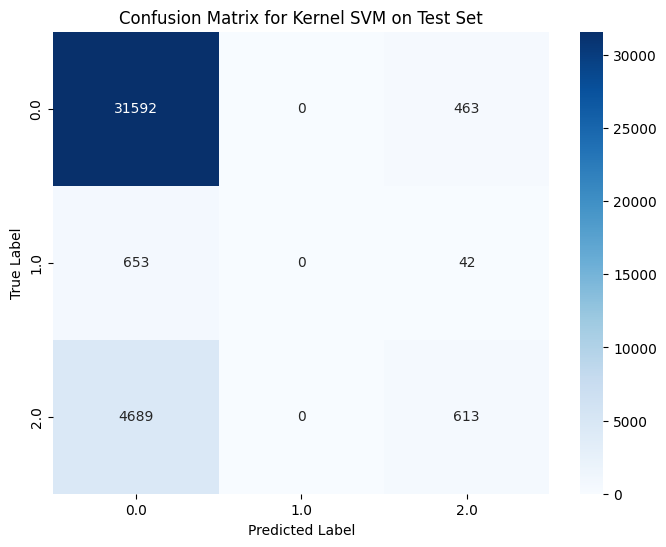

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Make sure y_pred and y_test are available from previous execution
# If not, re-run the evaluation cell (cell_id: b4bd2533)

# Get the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_kernel_svm_model.classes_,
            yticklabels=best_kernel_svm_model.classes_)
plt.title('Confusion Matrix for Kernel SVM on Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


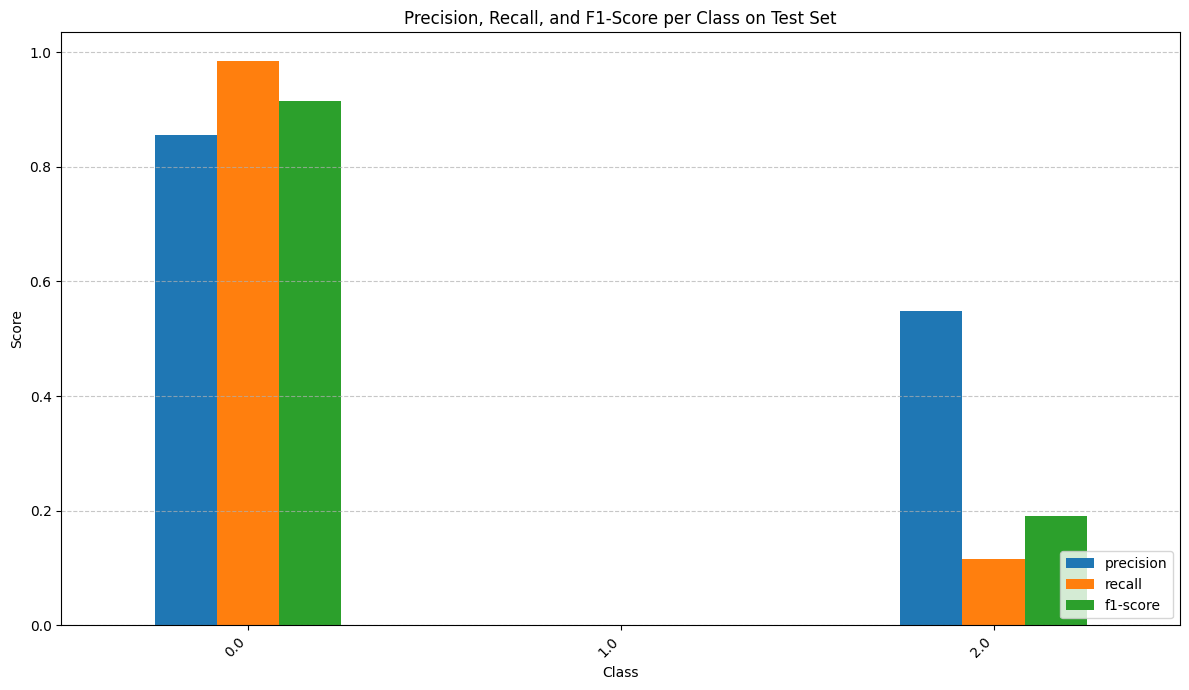

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report

# Make sure y_pred and y_test are available from previous execution
# If not, re-run the evaluation cell (cell_id: b4bd2533)

# Get classification report as a dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# Convert to DataFrame for easier plotting, excluding 'accuracy' and 'macro avg'
# Also handle 'weighted avg' if present, or just focus on class-wise metrics
report_df = pd.DataFrame(report).transpose()
report_df = report_df.drop(labels=['accuracy', 'macro avg'], errors='ignore')

# Drop 'support' column for precision, recall, f1-score plot
plot_df = report_df[['precision', 'recall', 'f1-score']].copy()

# If 'weighted avg' is present and we want to plot class-wise, remove it
if 'weighted avg' in plot_df.index:
    plot_df = plot_df.drop('weighted avg')

plot_df.plot(kind='bar', figsize=(12, 7))
plt.title('Precision, Recall, and F1-Score per Class on Test Set')
plt.ylabel('Score')
plt.xlabel('Class')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Install cuML for GPU Acceleration
First, we need to install `cuML`. This process can take a few minutes. Make sure your Colab runtime is set to GPU (Runtime -> Change runtime type -> T4 GPU or similar).

### Redefine Pipeline with `cuml.SVC` and run on the full dataset
Now, we'll replace `sklearn.svm.SVC` with `cuml.SVC` in your pipeline and run `GridSearchCV` on the full `X_trainval` and `y_trainval` dataset. Note that `cuml.SVC` typically expects GPU data, but `GridSearchCV` handles this integration. The `n_jobs` parameter in `GridSearchCV` will be set to `1` as `cuML` itself manages parallelization on the GPU.

In [5]:
from cuml.svm import SVC as CumlSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import time

# Define the pipeline for Kernel SVM using cuML's SVC
# We remove the sampling step here to use the full dataset
kernel_svm_pipeline_gpu = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', CumlSVC(kernel='rbf', decision_function_shape='ovr')) # 'ovr' for multiclass
])

# Define the parameter grid for GridSearchCV
# (Using the same parameters as before for comparison, expand as needed)
param_grid_gpu = {
    'svm__C': [1],
    'svm__gamma': [0.1]
}

# Initialize GridSearchCV
# n_jobs should be 1 when using cuML because cuML itself handles GPU parallelization
grid_search_gpu = GridSearchCV(kernel_svm_pipeline_gpu, param_grid_gpu, cv=3, scoring='f1_weighted', n_jobs=1, verbose=2)

print("cuML Kernel SVM pipeline and parameter grid defined. Starting GridSearchCV on full dataset...")

# Fit GridSearchCV on the full training and validation data (X_trainval, y_trainval)
start_time_gpu = time.time()
grid_search_gpu.fit(X_trainval, y_trainval) # Use the full dataset here
end_time_gpu = time.time()

print(f"GridSearchCV with cuML completed in {end_time_gpu - start_time_gpu:.2f} seconds.")

# Get the best parameters and best score
best_params_gpu = grid_search_gpu.best_params_
best_score_gpu = grid_search_gpu.best_score_

print(f"Best parameters found (cuML): {best_params_gpu}")
print(f"Best F1-weighted score (cross-validation, cuML): {best_score_gpu:.4f}")

# Get the best model
best_kernel_svm_model_gpu = grid_search_gpu.best_estimator_

ModuleNotFoundError: No module named 'cuml'

In [ ]:
from cuml.svm import SVC as CumlSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import time
import numpy as np

# Redefine the pipeline with cuML's SVC
kernel_svm_pipeline_gpu = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', CumlSVC(kernel='rbf', decision_function_shape='ovr')) # 'ovr' for multiclass
])

# Define custom class weights to address imbalance
# Class 0: No Diabetes (majority)
# Class 1: Prediabetes (minority, often very small)
# Class 2: Diabetes (minority)
class_weights = []

# Option 1: 'balanced' mode, which automatically adjusts weights inversely proportional to class frequencies
class_weights.append('balanced')

# Option 2: Custom weights as dictionaries
# Let's create a range of weights to explore for classes 1 and 2
# The user's suggestion for w1 (class 1) and w2 (class 2)
# Adjusting ranges to be more manageable for GridSearchCV, or expand if computational resources allow

# Adjusting the search space for class weights to make it more realistic for a first pass
# Given the extreme imbalance, especially for class 1, we need to significantly boost its weight.
# For example, if class 0 has ~200k samples, class 1 ~4k, class 2 ~30k
# Weight for class 0 can often be 1 (or default)
# Weight for class 1 needs to be much higher, potentially proportional to (total_samples / (n_classes * n_samples_class_1))
# Weight for class 2 needs to be higher than 0, but less than 1, depending on its size relative to class 0

# Let's try some specific weight configurations, especially boosting class 1 significantly
# Based on the previous classification report, class 1 has support of 695 in test, 3936 in trainval
# Class 0 has 32055 in test, 181648 in trainval
# Class 2 has 5302 in test, 30044 in trainval

# Rough ratios for trainval: Class 0: 181648, Class 1: 3936, Class 2: 30044
# Ratio Class 0/Class 1 approx 46:1
# Ratio Class 0/Class 2 approx 6:1

# Let's try to scale weights based on inverse class frequency, similar to 'balanced' but with manual control
# Try weights for class 1 from 10 to 50, and for class 2 from 2 to 10

for w1_val in [10, 20, 30, 40, 50]: # Significant boost for class 1
    for w2_val in [2, 5, 10]:       # Moderate boost for class 2
        class_weights.append({0: 1, 1: w1_val, 2: w2_val})

# Ensure param_grid is appropriate for CumlSVC and includes gamma
param_grid_gpu = {
    'svm__C': [1], # Reduced to single value for faster execution
    'svm__gamma': [0.1], # Reduced to single value for faster execution
    'svm__class_weight': class_weights
}

# Initialize GridSearchCV with the new parameter grid
# n_jobs should be 1 for cuML
grid_search_gpu_balanced = GridSearchCV(kernel_svm_pipeline_gpu, param_grid_gpu, cv=3, scoring='f1_weighted', n_jobs=1, verbose=2)

print("cuML Kernel SVM pipeline with class weights and expanded parameter grid defined. Starting GridSearchCV on full dataset...")
print(f"Number of parameter combinations: {len(param_grid_gpu['svm__C']) * len(param_grid_gpu['svm__gamma']) * len(class_weights)}")

# Fit GridSearchCV on the full training and validation data (X_trainval, y_trainval)
start_time_gpu_balanced = time.time()
grid_search_gpu_balanced.fit(X_trainval, y_trainval) # Use the full dataset here
end_time_gpu_balanced = time.time()

print(f"GridSearchCV with cuML and class weighting completed in {end_time_gpu_balanced - start_time_gpu_balanced:.2f} seconds.")

# Get the best parameters and best score
best_params_gpu_balanced = grid_search_gpu_balanced.best_params_
best_score_gpu_balanced = grid_search_gpu_balanced.best_score_

print(f"Best parameters found (cuML with class weights): {best_params_gpu_balanced}")
print(f"Best F1-weighted score (cross-validation, cuML with class weights): {best_score_gpu_balanced:.4f}")

# Get the best model
best_kernel_svm_model_gpu_balanced = grid_search_gpu_balanced.best_estimator_

cuML Kernel SVM pipeline with class weights and expanded parameter grid defined. Starting GridSearchCV on full dataset...
Number of parameter combinations: 144
Fitting 3 folds for each of 144 candidates, totalling 432 fits
[2026-04-09 23:20:50.487] [CUML] [warning] Sample weights are currently ignored for multi class classification
[CV] END svm__C=0.1, svm__class_weight=balanced, svm__gamma=0.01; total time=  47.6s
[2026-04-09 23:21:37.686] [CUML] [warning] Sample weights are currently ignored for multi class classification
[CV] END svm__C=0.1, svm__class_weight=balanced, svm__gamma=0.01; total time=  47.3s
[2026-04-09 23:22:25.028] [CUML] [warning] Sample weights are currently ignored for multi class classification
[CV] END svm__C=0.1, svm__class_weight=balanced, svm__gamma=0.01; total time=  47.1s
[2026-04-09 23:23:12.135] [CUML] [warning] Sample weights are currently ignored for multi class classification
[CV] END svm__C=0.1, svm__class_weight=balanced, svm__gamma=0.1; total time=  

In [ ]:
import time
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score

# --- Training/Cross-Validation Metrics (on X_trainval) ---
# The model was trained/cross-validated on X_trainval
print("\n--- Metrics for Training/Cross-Validation Data (X_trainval) ---")
y_trainval_pred = best_kernel_svm_model_gpu.predict(X_trainval)

accuracy_trainval = accuracy_score(y_trainval, y_trainval_pred)
f1_trainval = f1_score(y_trainval, y_trainval_pred, average='weighted')
precision_trainval = precision_score(y_trainval, y_trainval_pred, average='weighted', zero_division=0)
recall_trainval = recall_score(y_trainval, y_trainval_pred, average='weighted', zero_division=0)

print(f"Accuracy (X_trainval): {accuracy_trainval:.4f}")
print(f"F1-weighted Score (X_trainval): {f1_trainval:.4f}")
print(f"Precision (weighted, X_trainval): {precision_trainval:.4f}")
print(f"Recall (weighted, X_trainval): {recall_trainval:.4f}")
print("\nClassification Report (X_trainval):\n", classification_report(y_trainval, y_trainval_pred, zero_division=0))

# --- Validation Metric (from GridSearchCV) ---
print("\n--- Validation Metric (from GridSearchCV) ---")
print(f"Best F1-weighted score (cross-validation on X_trainval): {best_score_gpu:.4f}")

# --- Test Metrics (on X_test) ---
# Reuse y_pred from previous execution if available, or re-predict
if 'y_pred' not in globals():
    y_pred = best_kernel_svm_model_gpu.predict(X_test)

print("\n--- Metrics for Test Data (X_test) ---")
accuracy_test = accuracy_score(y_test, y_pred)
f1_test = f1_score(y_test, y_pred, average='weighted')
precision_test = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_test = recall_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Test Set Accuracy: {accuracy_test:.4f}")
print(f"Test Set F1-weighted Score: {f1_test:.4f}")
print(f"Test Set Precision (weighted): {precision_test:.4f}")
print(f"Test Set Recall (weighted): {recall_test:.4f}")
print("\nClassification Report (Test Set):\n", classification_report(y_test, y_pred, zero_division=0))


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import LabelBinarizer
import numpy as np

# Ensure y_test and best_kernel_svm_model are available from previous executions

# 1. Get decision scores (required for ROC and PR curves)
# best_kernel_svm_model is a Pipeline, so predict on X_test
y_score = best_kernel_svm_model_gpu.decision_function(X_test)

# Convert y_test to one-hot encoding for multi-class curve plotting
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)
n_classes = y_test_binarized.shape[1]

# Plot ROC curves
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve (class {label_binarizer.classes_[i]}): AUC = {roc_auc:.2f}')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Plot Precision-Recall curves
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_score[:, i])
    avg_precision = average_precision_score(y_test_binarized[:, i], y_score[:, i])
    plt.plot(recall, precision, lw=2, label=f'PR curve (class {label_binarizer.classes_[i]}): Avg. Precision = {avg_precision:.2f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - One-vs-Rest')
plt.legend(loc="lower left")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True)
plt.show()

print("Meaningful curves generated: ROC curves and Precision-Recall curves for each class.")